In [1]:
!pip install tensorflow scikit-learn seaborn kaggle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# **TASK 1 — Patient Monitoring (LSTM)**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   heart_rate  1000 non-null   float64
 2   sys_bp      1000 non-null   float64
 3   dia_bp      1000 non-null   float64
 4   ecg         1000 non-null   float64
 5   event       1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [7]:
df.describe()

,Unnamed: 0,heart_rate,sys_bp,dia_bp,ecg,event
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,100.331000,122.068000,80.556000,-0.009360,0.04200
std,288.819436,7.196334,7.236694,2.803698,0.513567,0.20069
min,0.000000,85.000000,104.000000,73.000000,-1.464700,0.00000
25%,249.750000,94.000000,116.000000,79.000000,-0.368725,0.00000
50%,499.500000,101.000000,123.000000,81.000000,0.000050,0.00000
75%,749.250000,107.000000,128.000000,83.000000,0.333475,0.00000
max,999.000000,114.000000,137.000000,89.000000,1.621500,1.00000


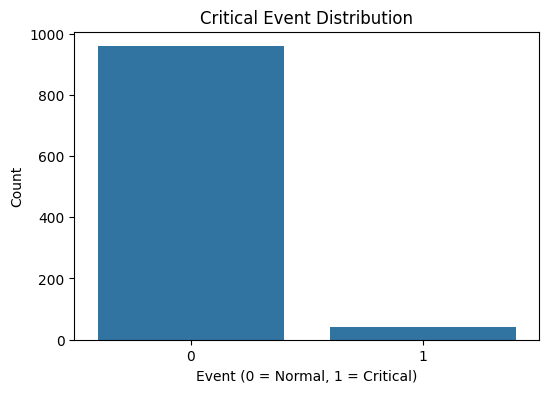

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="event", data=df)

plt.title("Critical Event Distribution")
plt.xlabel("Event (0 = Normal, 1 = Critical)")
plt.ylabel("Count")

plt.show()

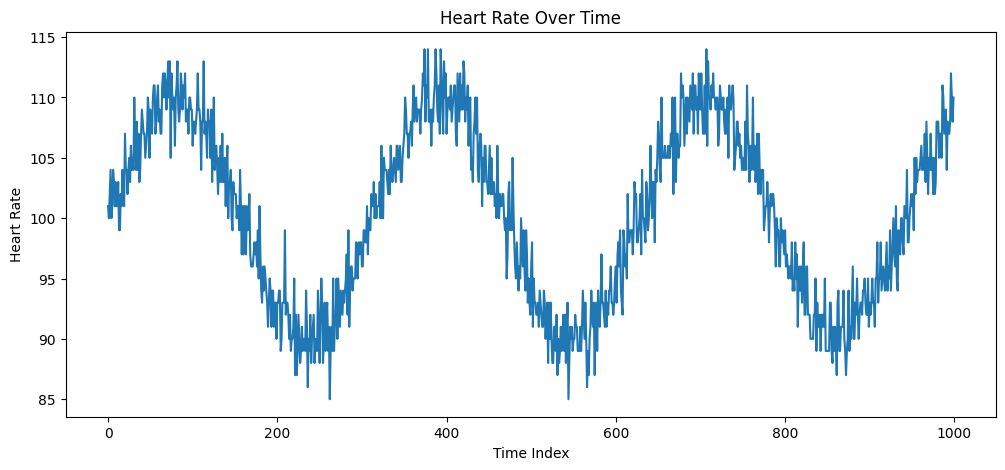

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["heart_rate"])

plt.title("Heart Rate Over Time")
plt.xlabel("Time Index")
plt.ylabel("Heart Rate")

plt.show()

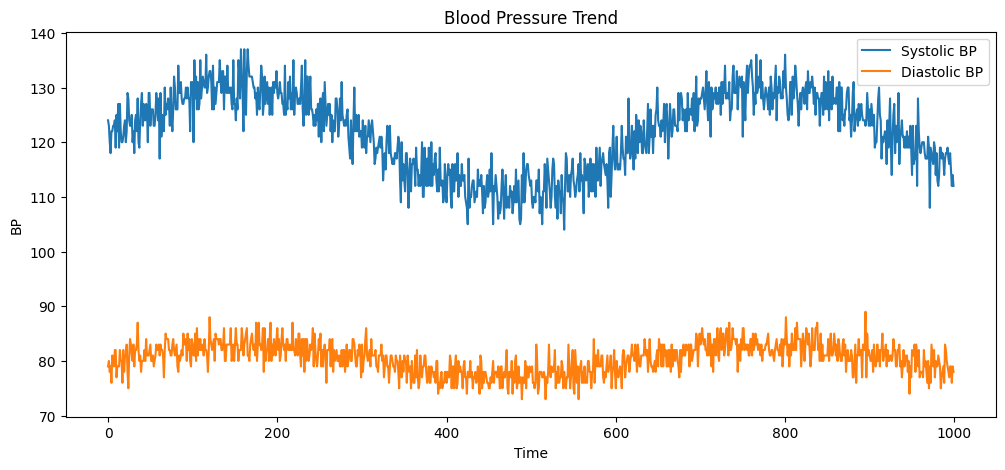

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df["sys_bp"], label="Systolic BP")
plt.plot(df["dia_bp"], label="Diastolic BP")

plt.legend()

plt.title("Blood Pressure Trend")
plt.xlabel("Time")
plt.ylabel("BP")

plt.show()

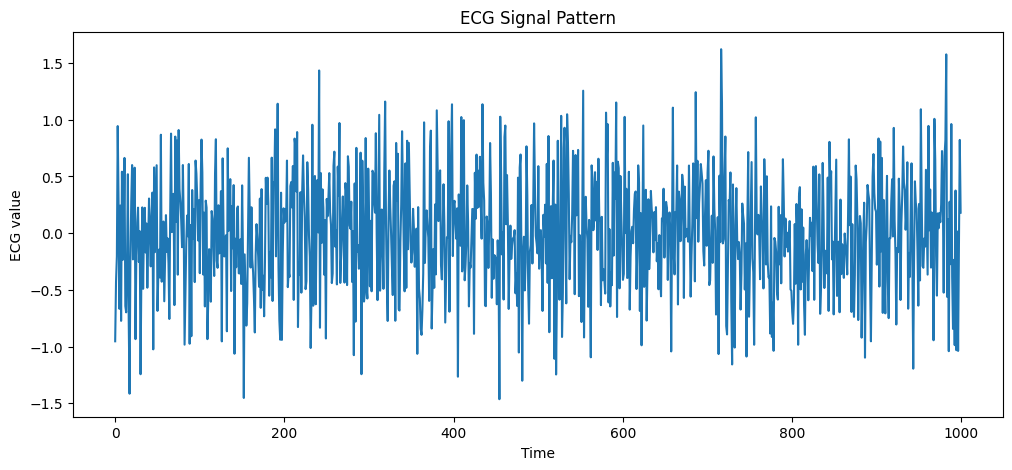

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["ecg"])

plt.title("ECG Signal Pattern")
plt.xlabel("Time")
plt.ylabel("ECG value")

plt.show()

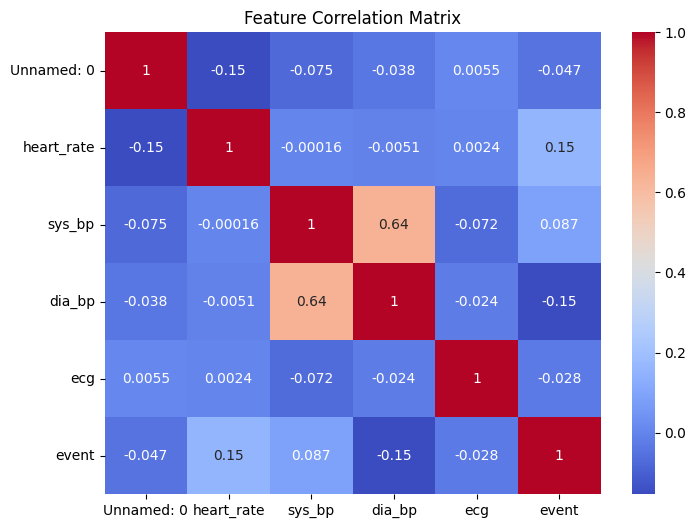

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

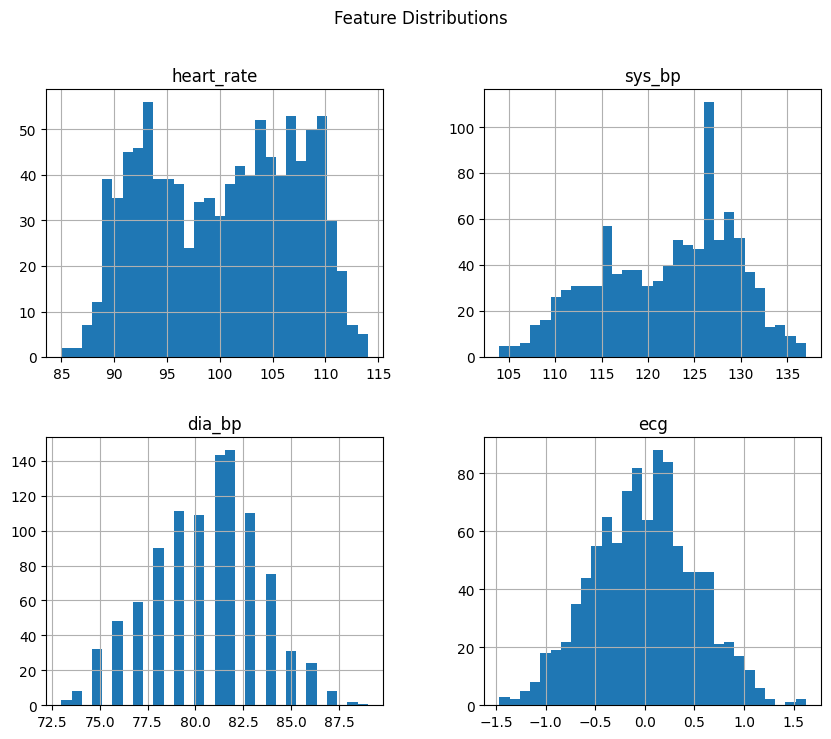

In [13]:
df[["heart_rate","sys_bp","dia_bp","ecg"]].hist(
    figsize=(10,8),
    bins=30
)

plt.suptitle("Feature Distributions")

plt.show()

In [16]:
features = df.drop("event", axis=1)

target = df["event"]

In [17]:
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(features)

In [18]:
X = []
y = []

window = 10

for i in range(len(scaled_features) - window):

    X.append(scaled_features[i:i+window])

    y.append(target.iloc[i+window])

X = np.array(X)
y = np.array(y)

print(X.shape)

(990, 10, 5)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9622 - loss: 0.1599 - val_accuracy: 0.9748 - val_loss: 0.1183
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9614 - loss: 0.1629 - val_accuracy: 0.9748 - val_loss: 0.1174
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9601 - loss: 0.1644 - val_accuracy: 0.9748 - val_loss: 0.1192
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9575 - loss: 0.1718 - val_accuracy: 0.9748 - val_loss: 0.1213
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9636 - loss: 0.1541 - val_accuracy: 0.9748 - val_loss: 0.1152
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9659 - loss: 0.1431 - val_accuracy: 0.9748 - val_loss: 0.1156
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9663 - loss: 0.1423 - val_accuracy: 0.9748 - val_loss: 0.1169
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9580 - loss: 0.1623 - val_accuracy: 0.9748 - v

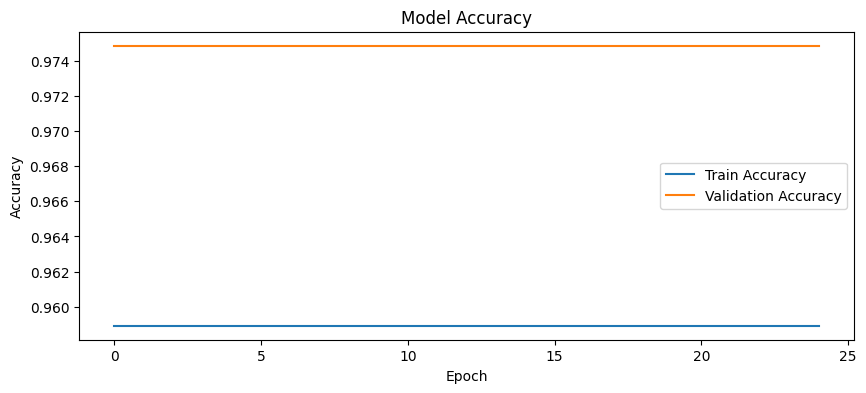

In [24]:
plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"], label="Train Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

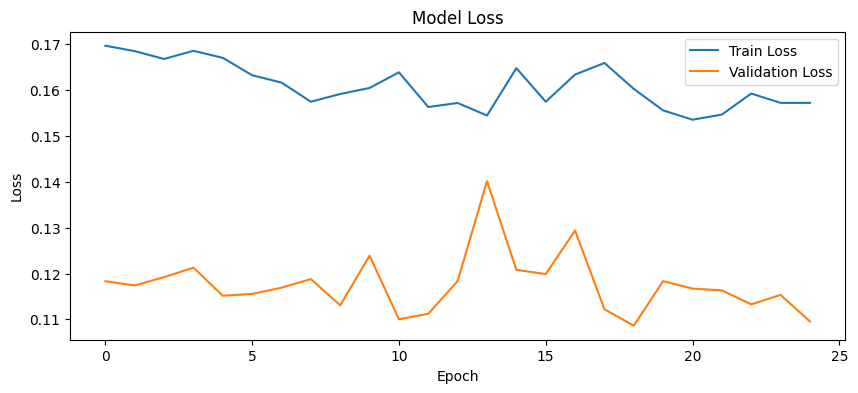

In [25]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [26]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


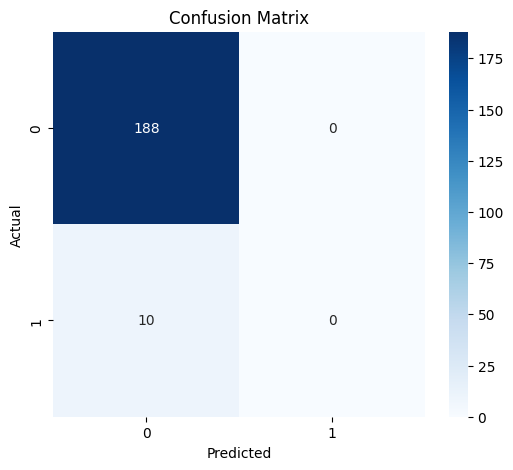

In [27]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [28]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       188
           1       0.00      0.00      0.00        10

    accuracy                           0.95       198
   macro avg       0.47      0.50      0.49       198
weighted avg       0.90      0.95      0.92       198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


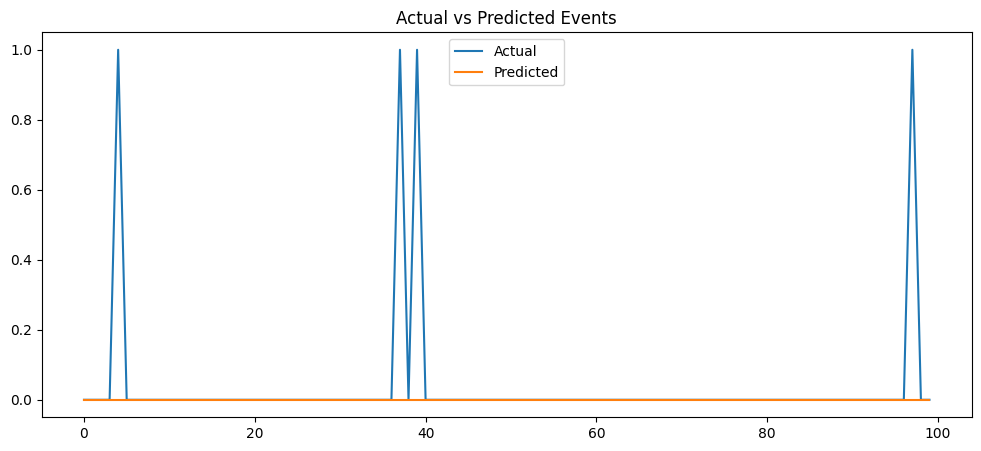

In [29]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:100], label="Actual")

plt.plot(predictions[:100], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Events")

plt.show()

# **2.LSTM Fraud Detection**

In [30]:
df = pd.read_csv("complex_fraud_dataset.csv")

df.head()

,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score,is_fraud
0,70,4862,18,4,1200.44,11,29,0.07,0.03,1,0.07,-0.46,0
1,62,4840,13,1,1347.32,4,32,0.09,0.06,1,0.06,-0.96,0
2,51,4258,10,3,1951.90,6,31,0.03,0.01,1,0.09,-0.26,0
3,48,4708,11,3,1235.69,5,25,0.18,0.05,1,0.07,0.00,0
4,64,3040,17,3,1483.73,8,20,0.05,0.17,1,0.04,-0.79,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   amount           5000 non-null   int64  
 1   balance          5000 non-null   int64  
 2   hour             5000 non-null   int64  
 3   day              5000 non-null   int64  
 4   time_since_last  5000 non-null   float64
 5   distance         5000 non-null   int64  
 6   speed            5000 non-null   int64  
 7   merchant_risk    5000 non-null   float64
 8   cardholder_risk  5000 non-null   float64
 9   device           5000 non-null   int64  
 10  ip_risk          5000 non-null   float64
 11  z_score          5000 non-null   float64
 12  is_fraud         5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.9 KB


In [32]:
df.describe()

,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000
mean,351.954000,4979.188600,12.813800,1.983800,1296.269338,104.70460,77.076200,0.175460,0.099882,0.90000,0.135162,0.499092,0.50000
std,893.255849,1004.092063,5.196396,1.413909,470.133959,305.42422,141.937502,0.233644,0.057512,0.30003,0.257574,1.573214,0.50005
min,-11.000000,1575.000000,0.000000,0.000000,1.000000,-5.00000,-9.000000,0.000000,0.000000,0.00000,0.000000,-1.690000,0.00000
25%,48.000000,4292.000000,10.000000,1.000000,1246.855000,3.00000,24.000000,0.060000,0.050000,1.00000,0.030000,-0.290000,0.00000
50%,62.000000,4980.500000,13.000000,2.000000,1410.240000,5.00000,31.500000,0.110000,0.100000,1.00000,0.060000,0.065000,0.50000
75%,79.000000,5650.250000,17.000000,3.000000,1556.685000,8.00000,40.000000,0.170000,0.150000,1.00000,0.080000,0.480000,1.00000
max,4348.000000,8939.000000,20.000000,4.000000,2119.440000,1637.00000,646.000000,1.000000,0.200000,1.00000,1.000000,5.000000,1.00000


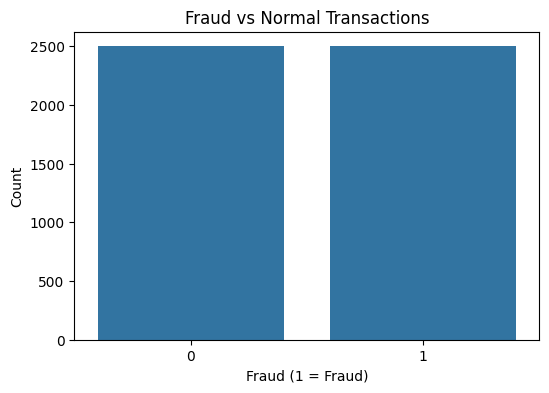

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud (1 = Fraud)")
plt.ylabel("Count")

plt.show()

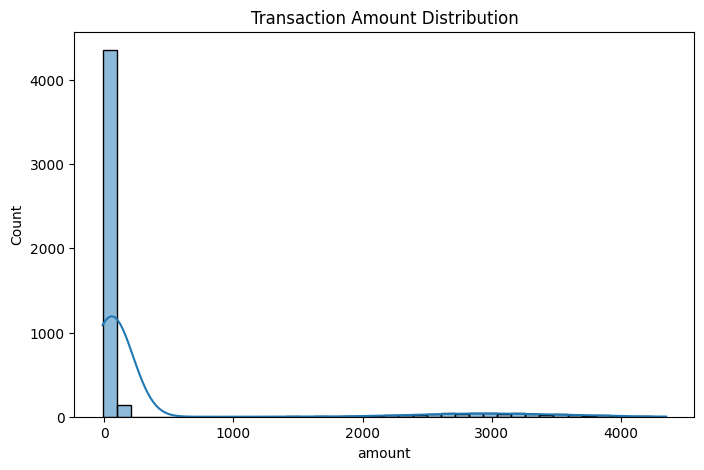

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=40, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

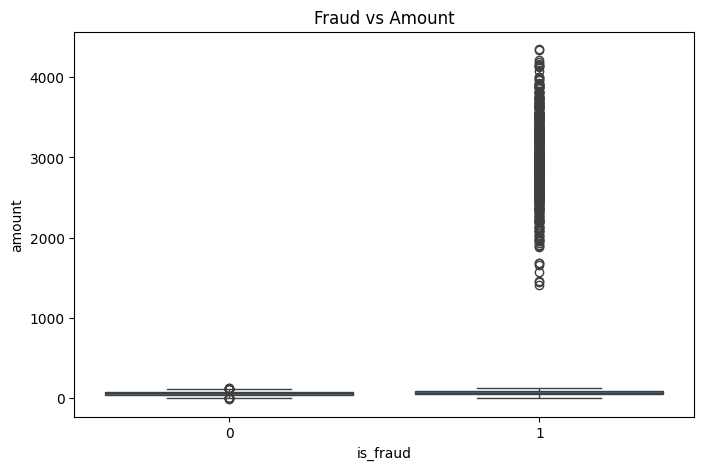

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_fraud", y="amount", data=df)

plt.title("Fraud vs Amount")

plt.show()

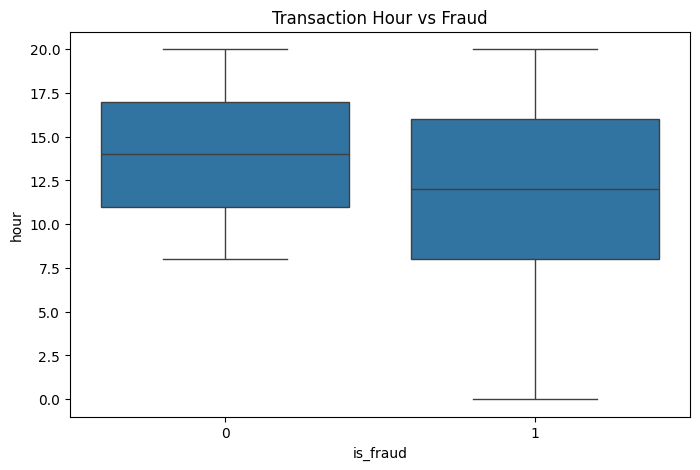

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_fraud", y="hour", data=df)

plt.title("Transaction Hour vs Fraud")

plt.show()

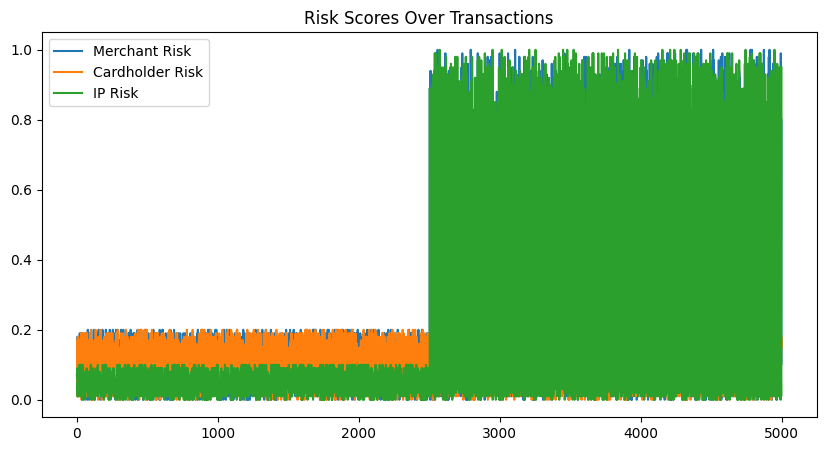

In [37]:
plt.figure(figsize=(10,5))

plt.plot(df["merchant_risk"], label="Merchant Risk")
plt.plot(df["cardholder_risk"], label="Cardholder Risk")
plt.plot(df["ip_risk"], label="IP Risk")

plt.legend()

plt.title("Risk Scores Over Transactions")

plt.show()

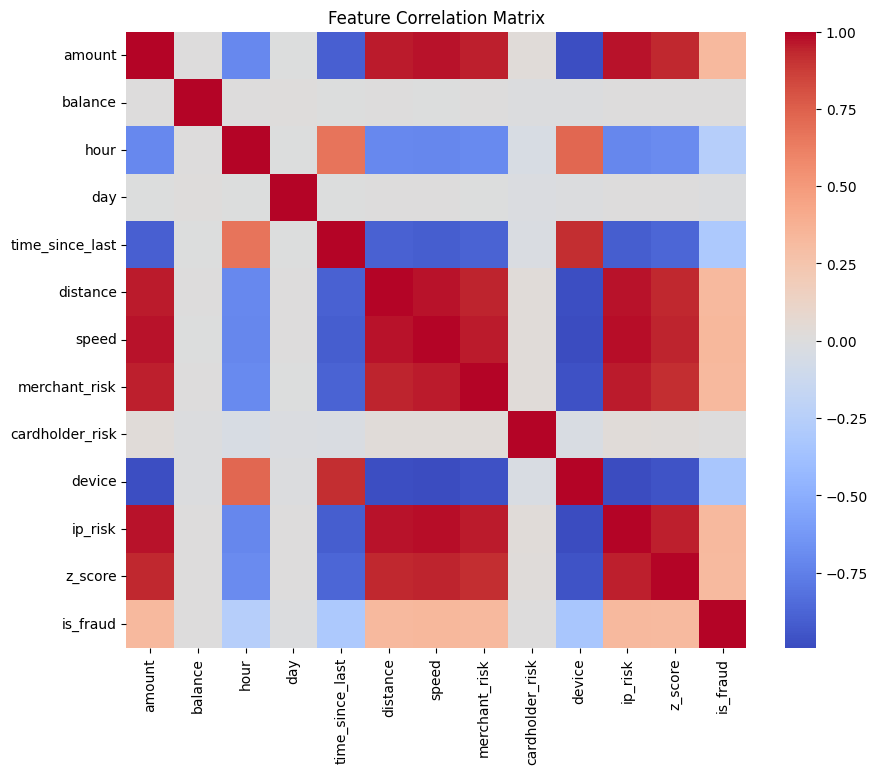

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

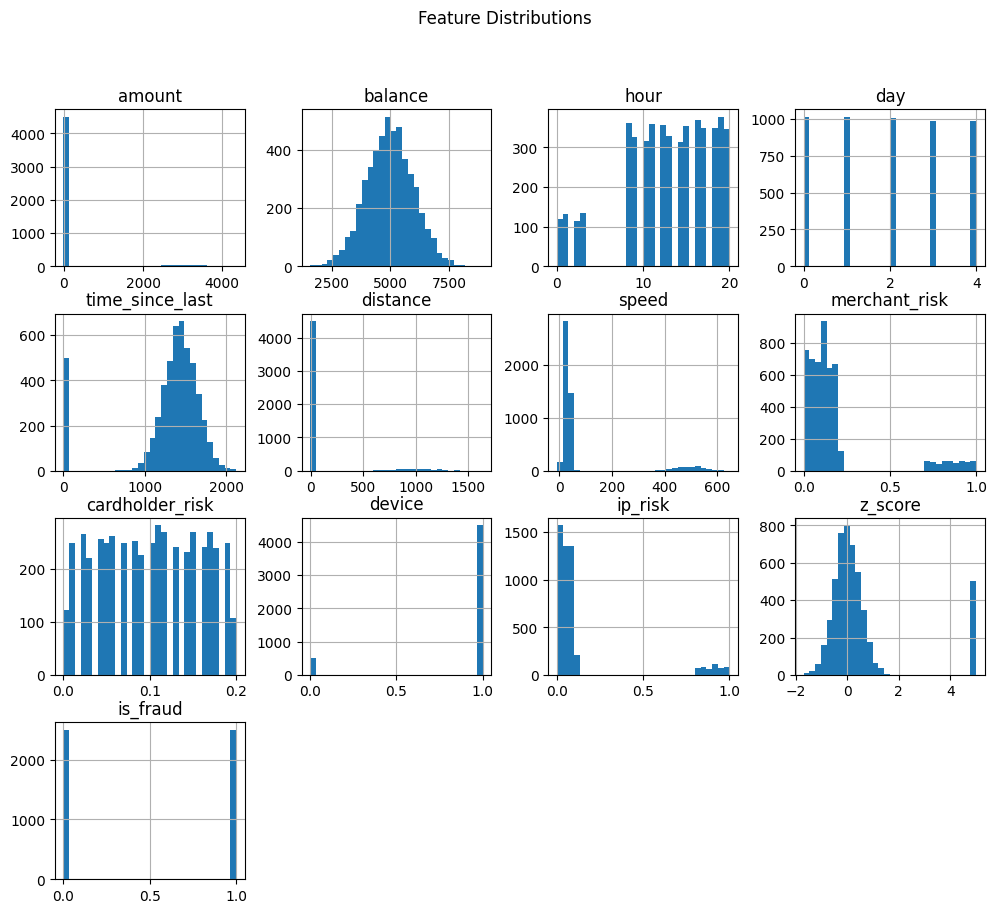

In [39]:
df.hist(figsize=(12,10), bins=30)

plt.suptitle("Feature Distributions")

plt.show()

In [40]:
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

In [41]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [42]:
X_seq = []
y_seq = []

window = 5

for i in range(len(X_scaled) - window):

    X_seq.append(X_scaled[i:i+window])

    y_seq.append(y.iloc[i+window])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

(4995, 5, 12)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

In [44]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_seq.shape[1], X_seq.shape[2])
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8487 - loss: 0.5861 - val_accuracy: 0.9600 - val_loss: 0.1301
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9624 - loss: 0.1149 - val_accuracy: 1.0000 - val_loss: 0.0193
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9992 - loss: 0.0207 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9993 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9983 - loss: 0.0141 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9993 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accuracy: 1.0000 - val_l

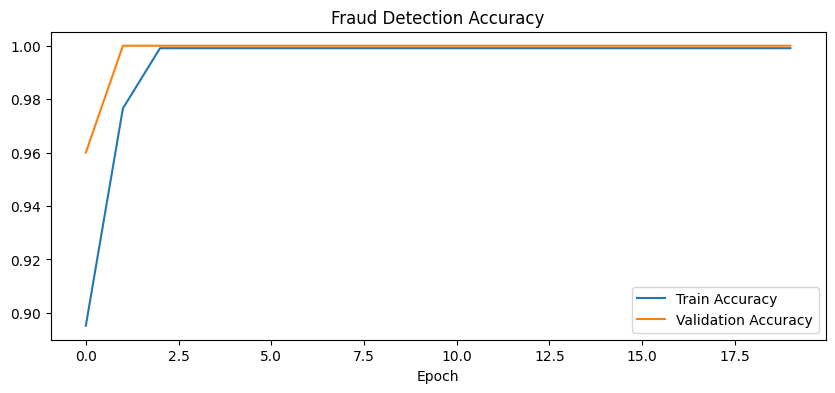

In [46]:
plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fraud Detection Accuracy")

plt.xlabel("Epoch")

plt.legend()

plt.show()

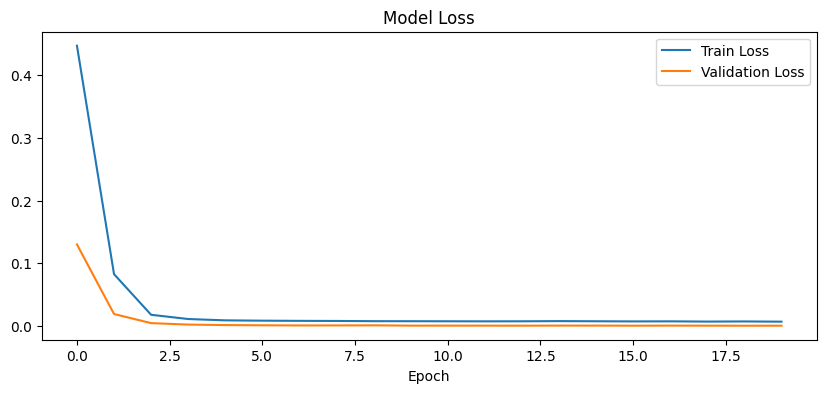

In [47]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.legend()

plt.show()

In [48]:
pred = model.predict(X_test)

pred = (pred > 0.5)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


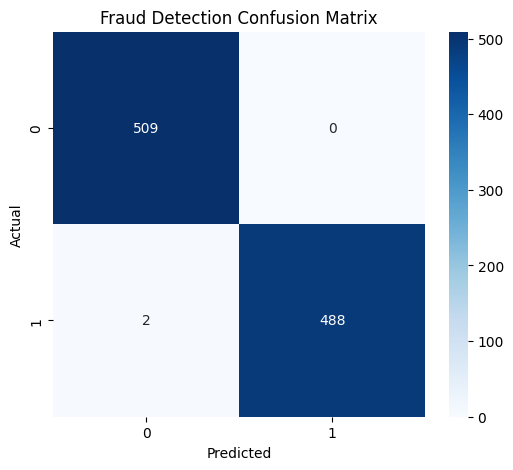

In [49]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Fraud Detection Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       509
           1       1.00      1.00      1.00       490

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



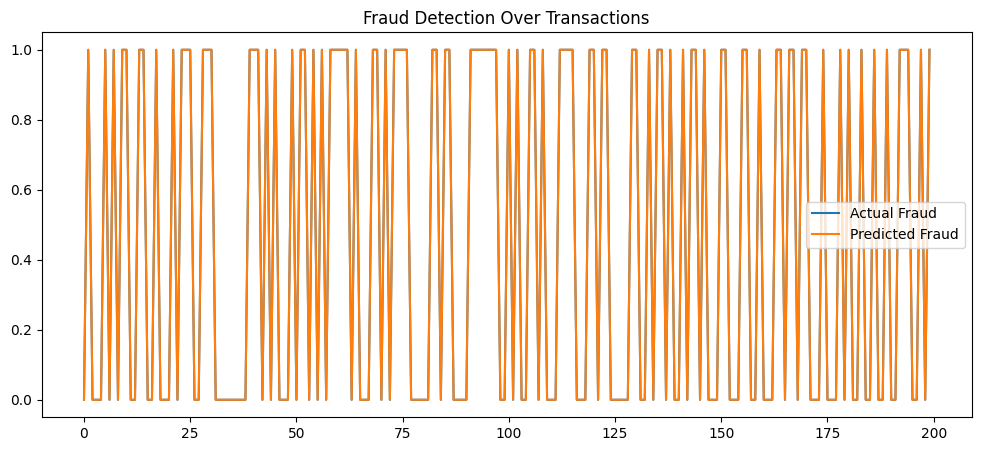

In [52]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual Fraud")

plt.plot(pred[:200], label="Predicted Fraud")

plt.legend()

plt.title("Fraud Detection Over Transactions")

plt.show()

# **3. LSTM Sentiment Analysis**

In [56]:
df = pd.read_csv("amazon_product_reviews.csv")

df.columns = ["reviewerID","productID","rating","timestamp"]

df.head()

,reviewerID,productID,rating,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,1.341101e+09
1,A2NWSAGRHCP8N5,0439886341,1.0,1.367194e+09
2,A2WNBOD3WNDNKT,0439886341,3.0,1.374451e+09
3,A1GI0U4ZRJA8WN,0439886341,1.0,1.334707e+09
4,A1QGNMC6O1VW39,0511189877,5.0,1.397434e+09


In [57]:
def sentiment(r):

    if r <= 2:
        return 0

    elif r == 3:
        return 1

    else:
        return 2


df["sentiment"] = df["rating"].apply(sentiment)

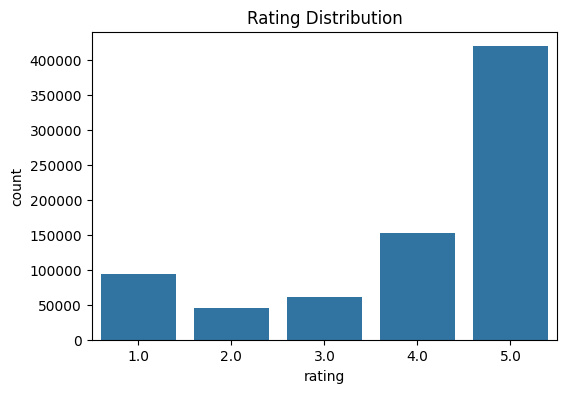

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(x="rating", data=df)

plt.title("Rating Distribution")

plt.show()

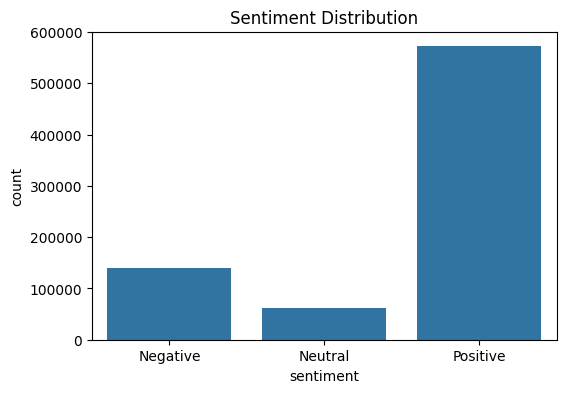

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")

plt.xticks([0,1,2],["Negative","Neutral","Positive"])

plt.show()

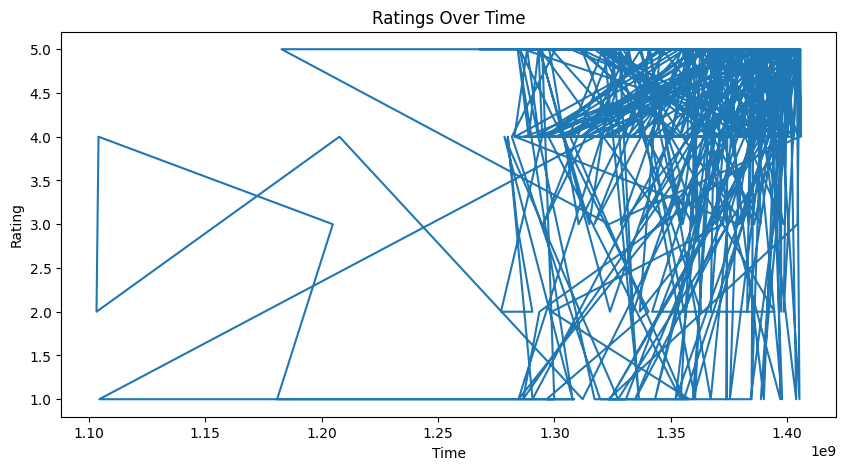

In [60]:
plt.figure(figsize=(10,5))

plt.plot(df["timestamp"][:500], df["rating"][:500])

plt.title("Ratings Over Time")

plt.xlabel("Time")

plt.ylabel("Rating")

plt.show()

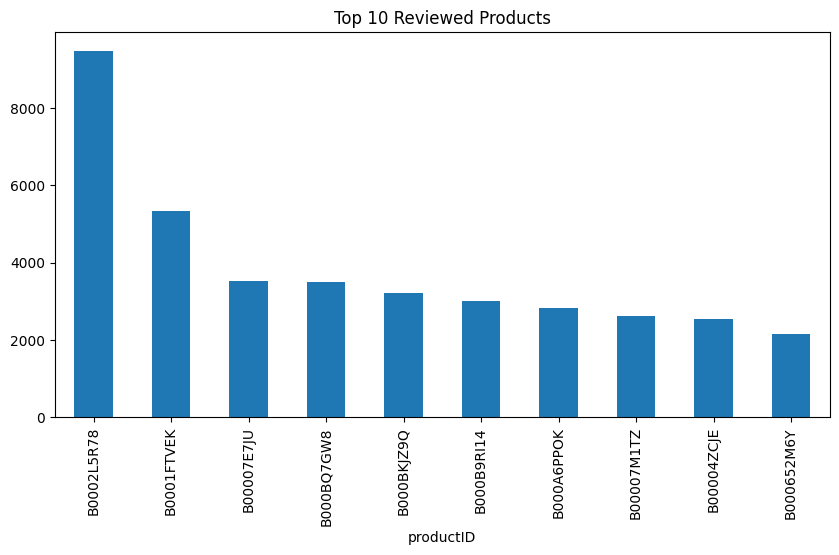

In [61]:
top_products = df["productID"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Reviewed Products")

plt.show()

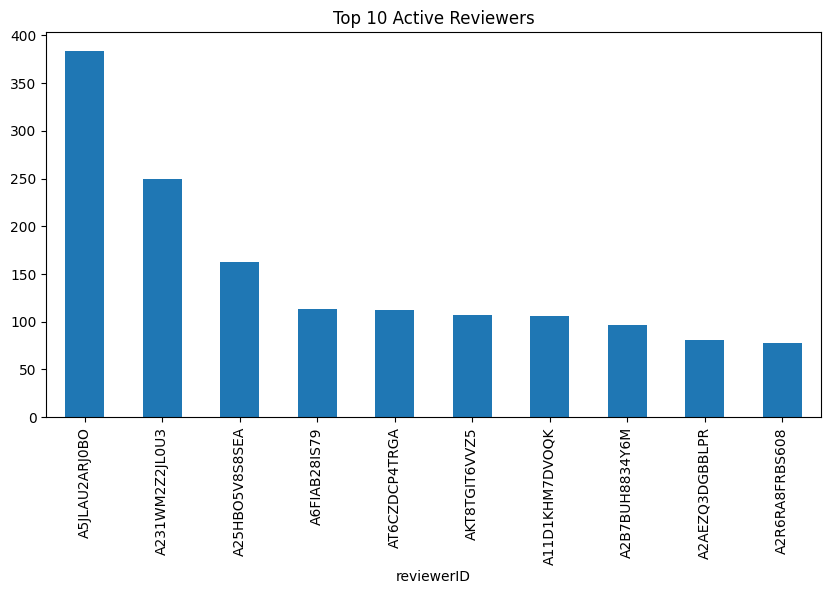

In [62]:
top_users = df["reviewerID"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Active Reviewers")

plt.show()

In [63]:
X = df[["rating","timestamp"]]

y = df["sentiment"]

In [64]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [65]:
X_seq = []
y_seq = []

window = 5

for i in range(len(X_scaled)-window):

    X_seq.append(X_scaled[i:i+window])

    y_seq.append(y.iloc[i+window])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

(772666, 5, 2)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

In [67]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_seq.shape[1], X_seq.shape[2])
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,667 (115.89 KB)

 Trainable params: 29,667 (115.89 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 73s 9ms/step - accuracy: 0.7401 - loss: 0.7142 - val_accuracy: 0.7414 - val_loss: 0.7060
Epoch 2/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - accuracy: 0.7422 - loss: 0.7042 - val_accuracy: 0.7402 - val_loss: 0.7058
Epoch 3/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.7416 - loss: 0.7051 - val_accuracy: 0.7410 - val_loss: 0.7053
Epoch 4/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.7422 - loss: 0.7039 - val_accuracy: 0.7412 - val_loss: 0.7051
Epoch 5/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - accuracy: 0.7416 - loss: 0.7050 - val_accuracy: 0.7413 - val_loss: 0.7049
Epoch 6/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - accuracy: 0.7418 - loss: 0.7050 - val_accuracy: 0.7409 - val_loss: 0.7046
Epoch 7/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.7422 - loss: 0.7040 - val_accuracy: 0.7409 - val_loss: 0.7058
Epoch 8/10
7727/7727 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.7419 - loss: 0

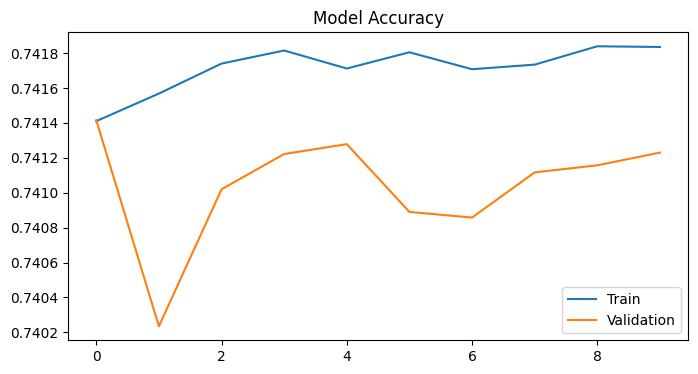

In [69]:
plt.figure(figsize=(8,4))

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Model Accuracy")

plt.legend()

plt.show()

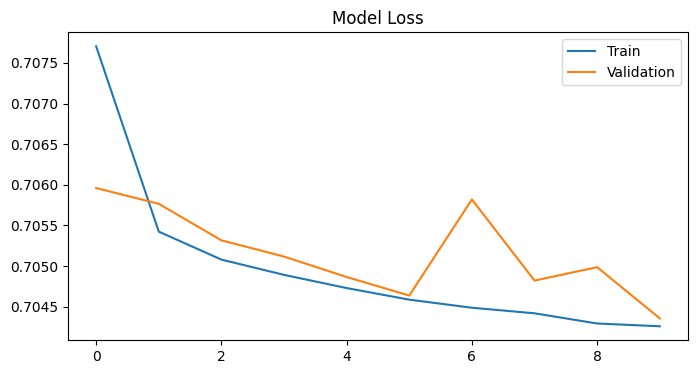

In [70]:
plt.figure(figsize=(8,4))

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Model Loss")

plt.legend()

plt.show()

In [71]:
pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

4830/4830 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


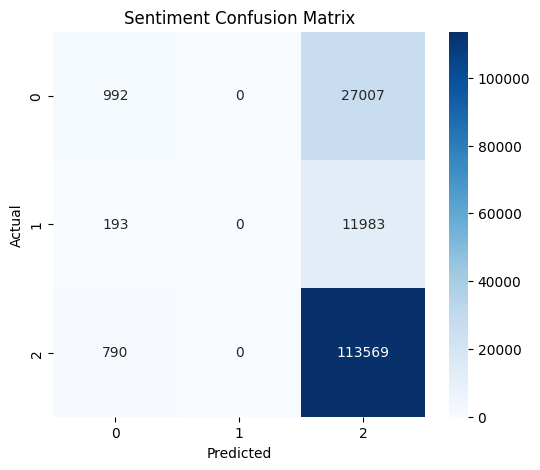

In [72]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Sentiment Confusion Matrix")

plt.show()

In [73]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.50      0.04      0.07     27999
           1       0.00      0.00      0.00     12176
           2       0.74      0.99      0.85    114359

    accuracy                           0.74    154534
   macro avg       0.42      0.34      0.31    154534
weighted avg       0.64      0.74      0.64    154534



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


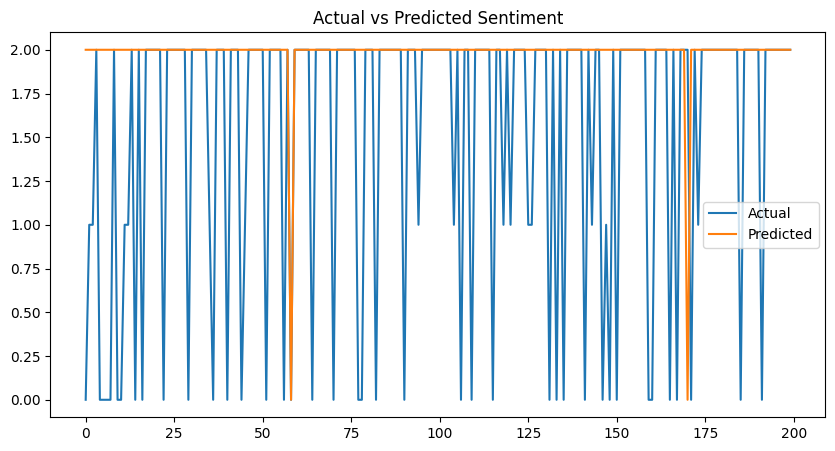

In [74]:
plt.figure(figsize=(10,5))

plt.plot(y_test[:200], label="Actual")

plt.plot(pred[:200], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Sentiment")

plt.show()

# **4. Retail Demand Forecasting using LSTM**

In [75]:
df = pd.read_csv("retail_demand_data.csv")

df.head()

,date,day_of_week,is_weekend,is_third_thursday,on_promotion,units_sold,is_holiday
0,2023-01-01,6,1,0,0,548,0
1,2023-01-02,0,0,0,1,483,0
2,2023-01-03,1,0,0,0,519,0
3,2023-01-04,2,0,0,0,530,0
4,2023-01-05,3,0,0,0,527,0


In [76]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

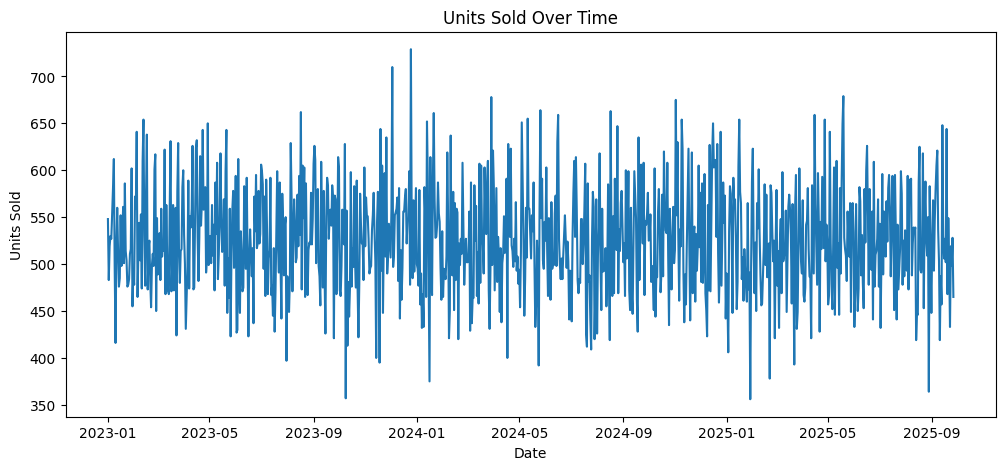

In [77]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["units_sold"])

plt.title("Units Sold Over Time")

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

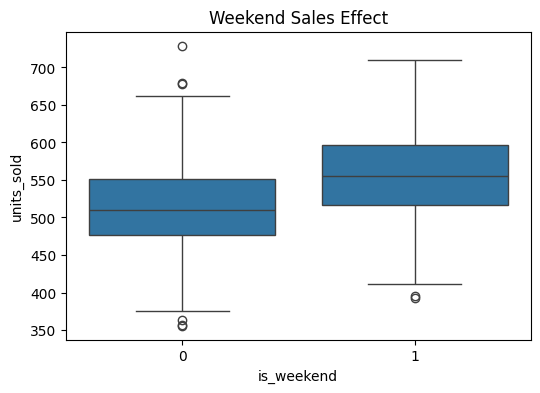

In [78]:
plt.figure(figsize=(6,4))

sns.boxplot(x="is_weekend", y="units_sold", data=df)

plt.title("Weekend Sales Effect")

plt.show()

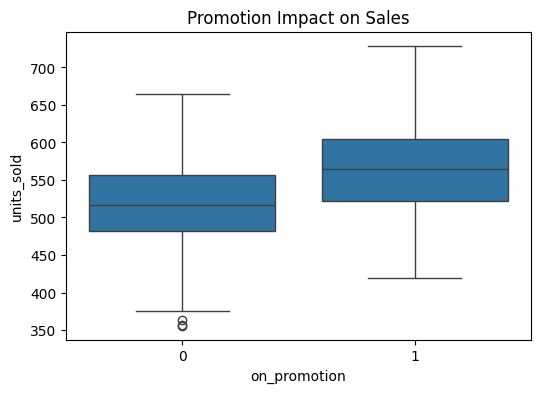

In [79]:
plt.figure(figsize=(6,4))

sns.boxplot(x="on_promotion", y="units_sold", data=df)

plt.title("Promotion Impact on Sales")

plt.show()

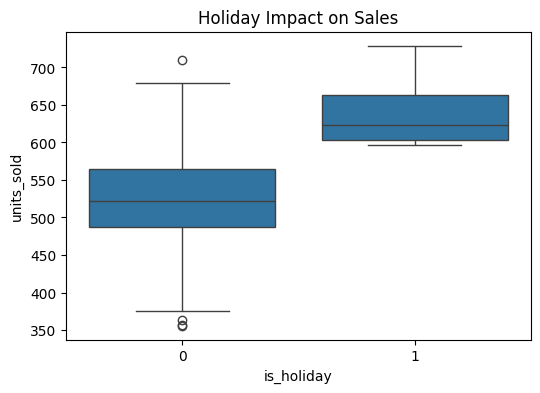

In [80]:
plt.figure(figsize=(6,4))

sns.boxplot(x="is_holiday", y="units_sold", data=df)

plt.title("Holiday Impact on Sales")

plt.show()

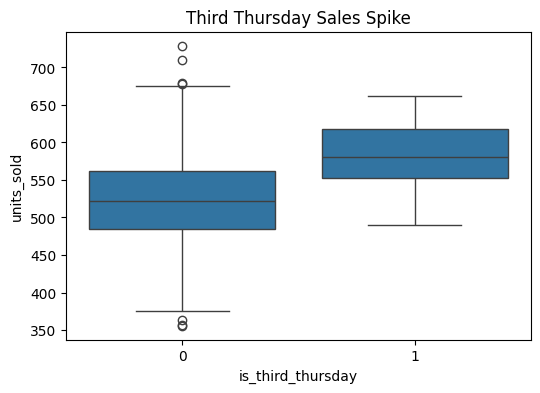

In [81]:
plt.figure(figsize=(6,4))

sns.boxplot(x="is_third_thursday", y="units_sold", data=df)

plt.title("Third Thursday Sales Spike")

plt.show()

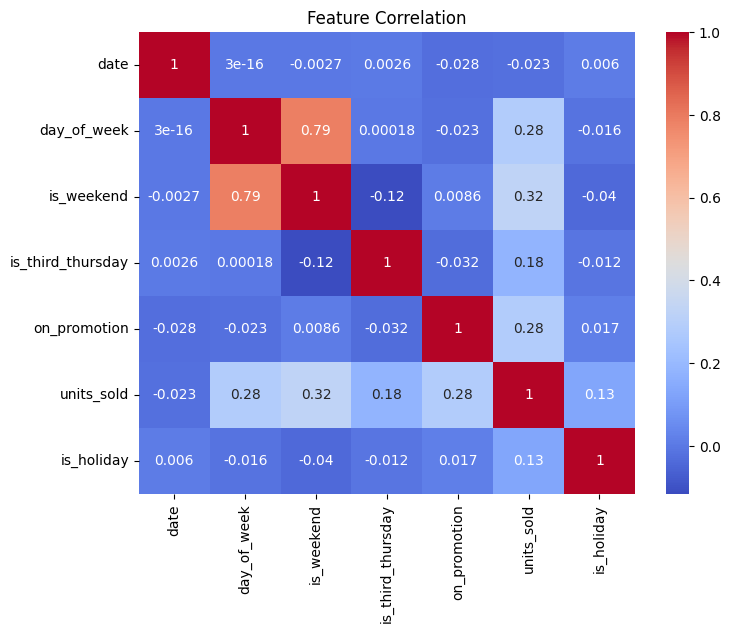

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [83]:
features = df[
    [
        "day_of_week",
        "is_weekend",
        "is_third_thursday",
        "on_promotion",
        "is_holiday",
        "units_sold"
    ]
]

In [84]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(features)

In [85]:
X = []
y = []

window = 14

for i in range(len(scaled) - window):

    X.append(scaled[i:i+window])

    y.append(scaled[i+window][5])   # units_sold index

X = np.array(X)
y = np.array(y)

print(X.shape)

(986, 14, 6)


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 14, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0916 - val_loss: 0.0403
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0298 - val_loss: 0.0289
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0264 - val_loss: 0.0288
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0237 - val_loss: 0.0282
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0264 - val_loss: 0.0290
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0255 - val_loss: 0.0282
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0268 - val_loss: 0.0278
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0239 - val_loss: 0.0275
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0218 - val_loss: 0.0273
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0229 - val_loss: 0.0299
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0235 - val_loss: 0.0282
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

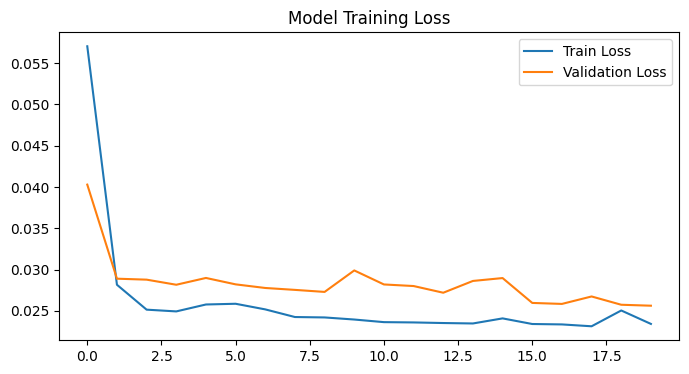

In [89]:
plt.figure(figsize=(8,4))

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Training Loss")

plt.legend()

plt.show()

In [90]:
pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [91]:
predicted = pred * scaler.data_range_[5] + scaler.data_min_[5]

actual = y_test * scaler.data_range_[5] + scaler.data_min_[5]

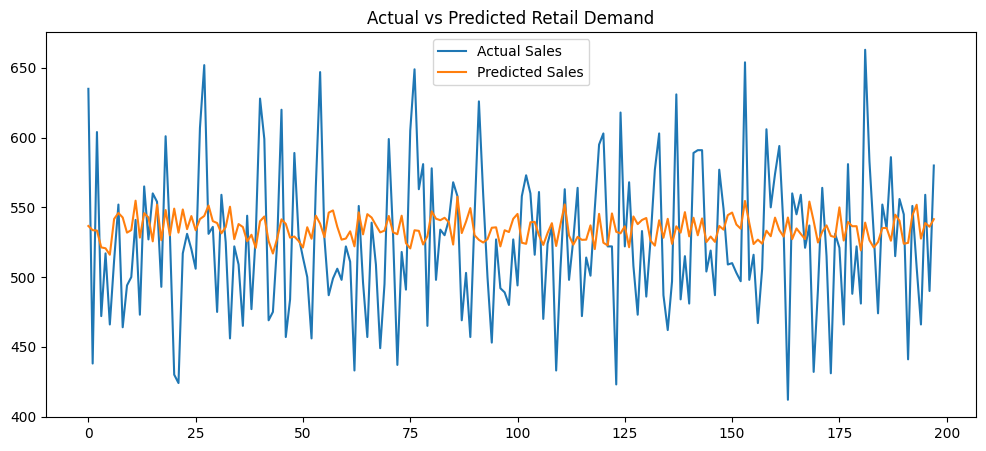

In [92]:
plt.figure(figsize=(12,5))

plt.plot(actual[:200], label="Actual Sales")

plt.plot(predicted[:200], label="Predicted Sales")

plt.legend()

plt.title("Actual vs Predicted Retail Demand")

plt.show()

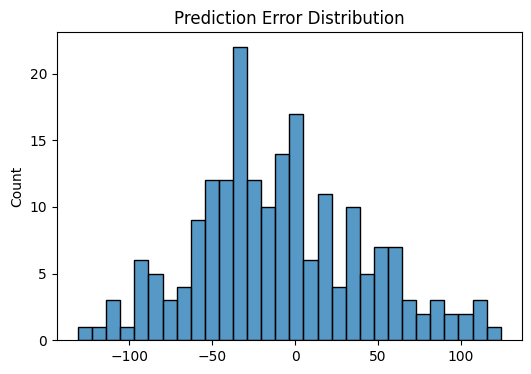

In [93]:
error = actual - predicted.flatten()

plt.figure(figsize=(6,4))

sns.histplot(error, bins=30)

plt.title("Prediction Error Distribution")

plt.show()

In [96]:
mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 41.65795749787128
RMSE: 51.5429927836909


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/tmp/ipykernel_215/1416384558.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_row[5] = next_pred


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


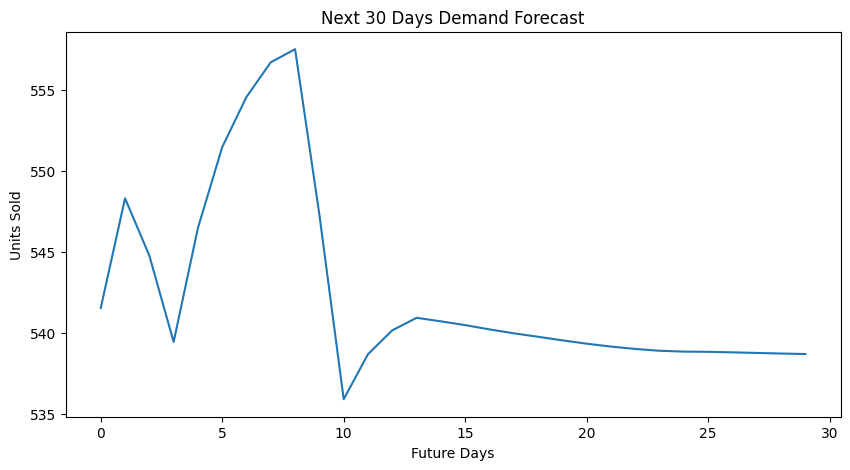

In [97]:
future_steps = 30

future_pred = []

last_seq = X_test[-1]

for i in range(future_steps):

    next_pred = model.predict(last_seq.reshape(1,14,6))

    future_pred.append(next_pred[0][0])

    new_row = last_seq[-1].copy()
    new_row[5] = next_pred

    last_seq = np.vstack([last_seq[1:], new_row])


future_pred = np.array(future_pred)

future_pred = future_pred * scaler.data_range_[5] + scaler.data_min_[5]

plt.figure(figsize=(10,5))

plt.plot(future_pred)

plt.title("Next 30 Days Demand Forecast")

plt.xlabel("Future Days")

plt.ylabel("Units Sold")

plt.show()